## Fraud Detection Project

### Introduction

Fraud detection is a critical task in financial systems, where the goal is to identify potentially fraudulent transactions while minimizing disruption to legitimate users. This project focuses on building a fraud detection framework that combines both rule-based scoring and machine learning techniques to assess transaction risk.

The objective is not only to maximize the detection of fraudulent transactions (high recall), but also to understand and manage the trade-off with false positives. This balance is essential in real-world applications, where excessive false alerts can negatively impact customer experience and operational efficiency.

To address this, multiple models are evaluated, thresholds are tuned based on business priorities, and model performance is analyzed using appropriate metrics such as precision, recall, and precision-recall curves.


In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Base.csv")
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000000 non-nul

In [3]:
df['device_distinct_emails_8w'].unique()        

array([ 1,  2,  0, -1])

In [4]:
pd.set_option('display.max_columns', None)
df.groupby("fraud_bool").mean(numeric_only=True)

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
fraud_bool,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.561313,0.494815,16.839647,86.273232,33.609125,1.025383,8.713907,1572.138693,5670.664988,4771.528849,4857.444566,184.923747,9.526521,130.469904,0.528423,0.418906,0.890112,10.843426,0.224533,512.303162,0.024962,7.537306,0.579571,1.017630,0.0,3.285582
1,0.686635,0.393161,5.861365,114.801161,40.858645,1.054615,3.962009,1622.311542,5183.913444,4613.138798,4755.844185,133.976426,7.443195,177.590353,0.661075,0.253060,0.850576,10.469580,0.084414,833.986762,0.050322,8.229520,0.341645,1.079427,0.0,3.565962


#### Hypothesis Testing

##### For numerical features

H₀: mean is the same for fraud and non-fraud

H₁: mean is different

In [5]:
from scipy.stats import ttest_ind

fraud = df[df["fraud_bool"] == 1]["income"]
non_fraud = df[df["fraud_bool"] == 0]["income"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [6]:
fraud = df[df["fraud_bool"] == 1]["name_email_similarity"]
non_fraud = df[df["fraud_bool"] == 0]["name_email_similarity"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 2.2555045287440515e-295


In [7]:
fraud = df[df["fraud_bool"] == 1]["prev_address_months_count"]
non_fraud = df[df["fraud_bool"] == 0]["prev_address_months_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.9858314927323405e-149


In [8]:
fraud = df[df["fraud_bool"] == 1]["current_address_months_count"]
non_fraud = df[df["fraud_bool"] == 0]["current_address_months_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 4.02208167285188e-249


In [9]:
fraud = df[df["fraud_bool"] == 1]["customer_age"]
non_fraud = df[df["fraud_bool"] == 0]["customer_age"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [10]:
fraud = df[df["fraud_bool"] == 1]["days_since_request"]
non_fraud = df[df["fraud_bool"] == 0]["days_since_request"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.5705247727066658


In [11]:
fraud = df[df["fraud_bool"] == 1]["intended_balcon_amount"]
non_fraud = df[df["fraud_bool"] == 0]["intended_balcon_amount"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 7.408216720914384e-133


In [12]:
fraud = df[df["fraud_bool"] == 1]["zip_count_4w"]
non_fraud = df[df["fraud_bool"] == 0]["zip_count_4w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.868283894070342e-07


In [13]:
fraud = df[df["fraud_bool"] == 1]["velocity_6h"]
non_fraud = df[df["fraud_bool"] == 0]["velocity_6h"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 5.0196890745190833e-64


In [14]:
fraud = df[df["fraud_bool"] == 1]["velocity_24h"]
non_fraud = df[df["fraud_bool"] == 0]["velocity_24h"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 4.9218828027128204e-29


In [15]:
fraud = df[df["fraud_bool"] == 1]["velocity_4w"]
non_fraud = df[df["fraud_bool"] == 0]["velocity_4w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 8.68740945769277e-31


In [16]:
fraud = df[df["fraud_bool"] == 1]["bank_branch_count_8w"]
non_fraud = df[df["fraud_bool"] == 0]["bank_branch_count_8w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 5.397590093755087e-31


In [17]:
fraud = df[df["fraud_bool"] == 1]["date_of_birth_distinct_emails_4w"]
non_fraud = df[df["fraud_bool"] == 0]["date_of_birth_distinct_emails_4w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [18]:
fraud = df[df["fraud_bool"] == 1]["credit_risk_score"]
non_fraud = df[df["fraud_bool"] == 0]["credit_risk_score"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [19]:
fraud = df[df["fraud_bool"] == 1]["email_is_free"]
non_fraud = df[df["fraud_bool"] == 0]["email_is_free"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.2167188766395695e-169


In [20]:
fraud = df[df["fraud_bool"] == 1]["phone_home_valid"]
non_fraud = df[df["fraud_bool"] == 0]["phone_home_valid"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.7348994849322754e-270


In [21]:
fraud = df[df["fraud_bool"] == 1]["phone_mobile_valid"]
non_fraud = df[df["fraud_bool"] == 0]["phone_mobile_valid"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.140351645803951e-39


In [22]:
fraud = df[df["fraud_bool"] == 1]["bank_months_count"]
non_fraud = df[df["fraud_bool"] == 0]["bank_months_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0012717662833232047


In [23]:
fraud = df[df["fraud_bool"] == 1]["has_other_cards"]
non_fraud = df[df["fraud_bool"] == 0]["has_other_cards"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 6.3475034012951e-271


In [24]:
fraud = df[df["fraud_bool"] == 1]["proposed_credit_limit"]
non_fraud = df[df["fraud_bool"] == 0]["proposed_credit_limit"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [25]:
fraud = df[df["fraud_bool"] == 1]["foreign_request"]
non_fraud = df[df["fraud_bool"] == 0]["foreign_request"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 5.7227304122397784e-64


In [26]:
fraud = df[df["fraud_bool"] == 1]["session_length_in_minutes"]
non_fraud = df[df["fraud_bool"] == 0]["session_length_in_minutes"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 2.26457112944074e-19


In [27]:
fraud = df[df["fraud_bool"] == 1]["keep_alive_session"]
non_fraud = df[df["fraud_bool"] == 0]["keep_alive_session"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [28]:
fraud = df[df["fraud_bool"] == 1]["device_distinct_emails_8w"]
non_fraud = df[df["fraud_bool"] == 0]["device_distinct_emails_8w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 2.2755392243268834e-279


In [29]:
fraud = df[df["fraud_bool"] == 1]["device_fraud_count"]
non_fraud = df[df["fraud_bool"] == 0]["device_fraud_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: nan


In [30]:
fraud = df[df["fraud_bool"] == 1]["month"]
non_fraud = df[df["fraud_bool"] == 0]["month"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 4.475818725834844e-40


##### Results of Statistical Tests for Numerical Features

Independent t-tests were conducted to evaluate whether numerical features differ significantly between fraudulent and non-fraudulent transactions.

The results show that all numerical features, with the exception of `days_since_request`, have p-values below the 0.05 significance level. This indicates that their mean values differ significantly between the two groups, suggesting that they are relevant predictors of fraud.

In contrast, `days_since_request` returned a p-value greater than 0.05, meaning that there is insufficient evidence to conclude a significant difference between fraud and non-fraud transactions for this feature.

As a result, this variable may have limited predictive power when considered independently. However, it may still be retained in the model to capture potential nonlinear effects or interactions with other features.


#### For categorical features

H₀: independent from fraud

H₁: dependent on fraud

In [31]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["payment_type"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


In [32]:
contingency = pd.crosstab(df["employment_status"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


In [33]:
contingency = pd.crosstab(df["housing_status"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


In [34]:
contingency = pd.crosstab(df["source"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.00011111400181929854


In [35]:
contingency = pd.crosstab(df["device_os"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


### Preparing data

In [36]:
X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]

In [37]:
X = pd.get_dummies(X, drop_first=True)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [39]:
y.value_counts(normalize=True)

fraud_bool
0    0.988971
1    0.011029
Name: proportion, dtype: float64

In [40]:
from sklearn.utils import class_weight

class_weights = "balanced"

#### Class Imbalance

The dataset exhibits a strong class imbalance, with fraudulent transactions representing only a small fraction of the total observations. This imbalance can bias the model toward predicting the majority class.

To address this issue, class weights will be used in the Logistic Regression and Random Forest models, ensuring that fraudulent cases are given higher importance during training.


### Training models

##### Model Selection Rationale

Three different machine learning models were selected to capture a range of modeling approaches and compare their performance on the fraud detection task.

**Logistic Regression** was chosen as a baseline model due to its simplicity, interpretability, and widespread use in classification problems. It provides a reference point to evaluate whether more complex models offer meaningful improvements.

**Random Forest** was selected as a tree-based ensemble method capable of capturing non-linear relationships and interactions between features. It is robust to noise and performs well on structured data.

**Gradient Boosting** was included as a more advanced ensemble technique that builds models sequentially, focusing on correcting previous errors. This approach is known to achieve strong performance in tabular datasets and is particularly effective in detecting subtle patterns, such as those present in fraud detection.

By comparing these three models, the analysis ensures a comprehensive evaluation across different levels of model complexity and learning strategies.


#### Logistic Model

In [55]:
# cross validation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std:", scores.std())

ROC-AUC scores: [0.84791913 0.88280271 0.89615662 0.87063213 0.87621968]
Mean ROC-AUC: 0.8747460549033415
Std: 0.015887742812691855


In [43]:
# confidence interval
import numpy as np

mean = scores.mean()
std = scores.std()
n = len(scores)

ci_lower = mean - 1.96 * (std / np.sqrt(n))
ci_upper = mean + 1.96 * (std / np.sqrt(n))

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [0.8608, 0.8887]


##### Cross-Validated Performance

A 5-fold cross-validation approach was used to evaluate the Logistic Regression model, ensuring robust performance estimation across different data splits. The model achieved a mean ROC-AUC of approximately 0.875.

To quantify the uncertainty of this estimate, a 95% confidence interval was computed, resulting in a range of approximately [0.86, 0.89]. This relatively narrow interval indicates that the model performs consistently across different folds and generalizes well to unseen data.


#### Random Forest

In [44]:
# cross validation
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,  
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# cross validation
scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC scores:", scores_rf)
print("Mean ROC-AUC:", scores_rf.mean())
print("Std:", scores_rf.std())

ROC-AUC scores: [0.76437524 0.80773776 0.84401431 0.81598052 0.81727508]
Mean ROC-AUC: 0.8098765830396324
Std: 0.025815990848340152


In [45]:
# confidence interval
mean = scores_rf.mean()
std = scores_rf.std()
n = len(scores_rf)

ci_lower = mean - 1.96 * (std / np.sqrt(n))
ci_upper = mean + 1.96 * (std / np.sqrt(n))

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [0.7872, 0.8325]


#### Gradient Boosting

In [46]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# cross validation
scores_gb = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1  
)

print("ROC-AUC scores:", scores_gb)
print("Mean ROC-AUC:", scores_gb.mean())
print("Std:", scores_gb.std())

ROC-AUC scores: [0.86747794 0.88771209 0.83014148 0.87060509 0.8729822 ]
Mean ROC-AUC: 0.8657837592535443
Std: 0.01912671877235696


In [47]:
# confidence interval
mean = scores_gb.mean()
std = scores_gb.std()
n = len(scores_gb)

ci_lower = mean - 1.96 * (std / np.sqrt(n))
ci_upper = mean + 1.96 * (std / np.sqrt(n))

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [0.8490, 0.8825]


#### Model Comparison

Three models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting. The primary metric used for comparison was the ROC-AUC score, which measures the ability of a model to distinguish between fraudulent and non-fraudulent transactions across all possible thresholds.

The results showed that **Logistic Regression** and **Gradient Boosting** achieved similar ROC-AUC scores, indicating comparable performance in ranking transactions by fraud risk. In contrast, the **Random Forest** model obtained a noticeably lower ROC-AUC score, suggesting weaker discrimination between classes.

As a result, Random Forest was discarded from further consideration. Since its ability to separate fraudulent from non-fraudulent cases was inferior, it was less suitable for a fraud detection task where accurate ranking of risk is critical.

To determine the most suitable model between the remaining candidates, additional evaluation steps were conducted. These included analyzing feature importance and interpretability, performing threshold tuning to optimize classification performance, and comparing recall scores to assess each model’s ability to correctly identify fraudulent transactions.

This multi-step evaluation ensures that the final model selection is not based solely on ranking performance, but also on its effectiveness in detecting fraud under practical decision thresholds.


### Feature Importance
#### Logistic Regression

In [56]:
import matplotlib.pyplot as plt

lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [59]:
def plot_logistic_coefficients(model, X, top_n=10):
    # Extract coefficients
    coeffs = pd.Series(
        pipeline.named_steps["model"].coef_[0],
        index=X.columns
    )
    # Get top features
    top_positive = coeffs.sort_values(ascending=False).head(top_n)
    top_negative = coeffs.sort_values().head(top_n)

    # Combine
    combined = pd.concat([top_negative, top_positive])

    # Plot
    plt.figure(figsize=(8, 6))
    combined.sort_values().plot(kind="barh")
    plt.axvline(0)
    plt.title("Logistic Regression Feature Impact")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    plt.show()

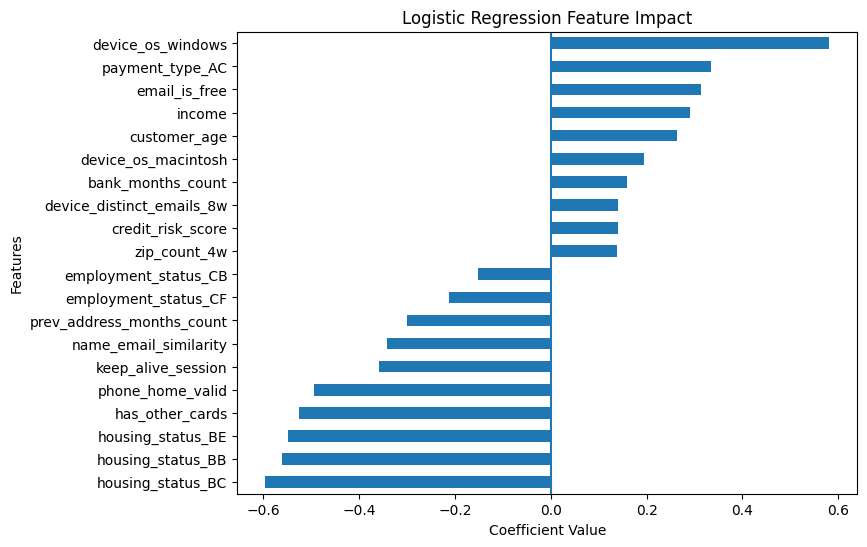

In [60]:
plot_logistic_coefficients(lr, X_train)

#### Gradient Boosting

In [51]:
gb.fit(X_train, y_train)

importances = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

device_os_windows                   0.133736
proposed_credit_limit               0.114866
credit_risk_score                   0.108522
name_email_similarity               0.074424
current_address_months_count        0.058778
phone_home_valid                    0.058173
income                              0.050397
has_other_cards                     0.047406
keep_alive_session                  0.044705
date_of_birth_distinct_emails_4w    0.038907
dtype: float64


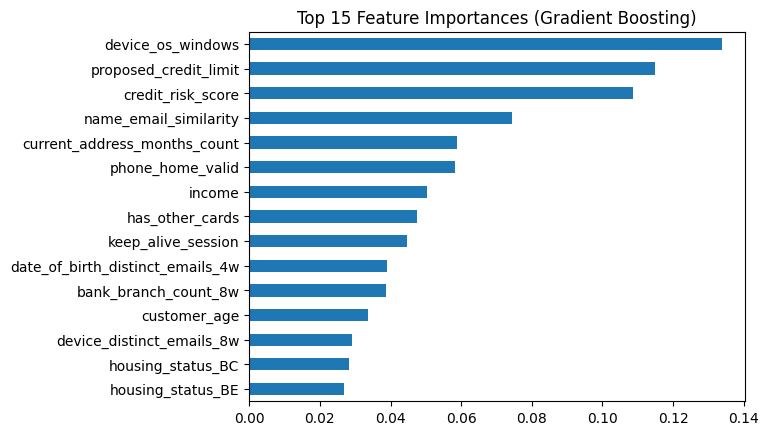

In [52]:
importances.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.gca().invert_yaxis()
plt.show()

### Threshold Tuning 
#### Logistic Regression

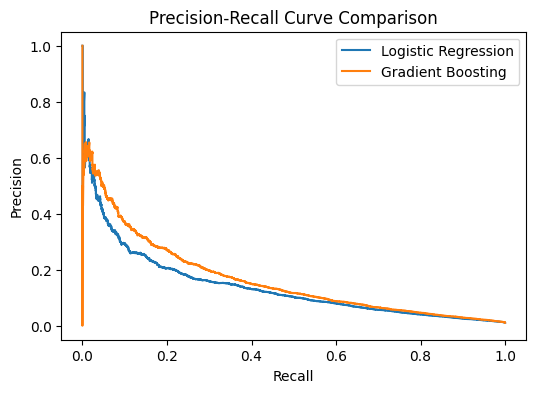

In [63]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_lr_proba)

# Logistic Regression
y_lr_proba = lr.predict_proba(X_test)[:, 1]
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_lr_proba)

# Gradient Boosting
y_gb_proba = gb.predict_proba(X_test)[:, 1]
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_gb_proba)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(recall_lr, precision_lr, label="Logistic Regression")
plt.plot(recall_gb, precision_gb, label="Gradient Boosting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

- Recall - % of frauds catched
- Precision - % of detected frauds that are actually fraud

In [64]:
# Build table
df_lr = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

# Choose BEST threshold
df_lr_filtered = df_lr[df_lr["recall"] >= 0.70]

best_lr = df_lr_filtered.sort_values(by="precision", ascending=False).iloc[0]

best_threshold_lr = best_lr["threshold"]

print(best_lr)

# Apply threshold
y_lr_pred = (y_lr_proba >= best_threshold_lr).astype(int)

# Compute recall
from sklearn.metrics import recall_score, precision_score

recall_lr = recall_score(y_test, y_lr_pred)
precision_lr = precision_score(y_test, y_lr_pred)

print("LR Recall:", recall_lr)
print("LR Precision:", precision_lr)

threshold    0.617035
precision    0.056899
recall       0.700773
Name: 172917, dtype: float64
LR Recall: 0.7007730786721237
LR Precision: 0.05689916183583798


#### Gradient Boosting

In [65]:
#gb.fit(X_train, y_train)

y_gb_proba = gb.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_gb_proba)

df_gb = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

df_gb_filtered = df_gb[df_gb["recall"] >= 0.70]

best_gb = df_gb_filtered.sort_values(by="precision", ascending=False).iloc[0]

best_threshold_gb = best_gb["threshold"]

print(best_gb)

y_gb_pred = (y_gb_proba >= best_threshold_gb).astype(int)

recall_gb = recall_score(y_test, y_gb_pred)
precision_gb = precision_score(y_test, y_gb_pred)

print("GB Recall:", recall_gb)
print("GB Precision:", precision_gb)

threshold    0.018310
precision    0.065558
recall       0.701228
Name: 175523, dtype: float64
GB Recall: 0.7012278308321964
GB Precision: 0.065558437141278


##### Threshold Optimization

Instead of relying on default classification thresholds, a custom threshold tuning approach was applied to better align model predictions with business objectives.

Using precision-recall curves, thresholds were evaluated to identify points where recall is maximized while maintaining acceptable precision. This allows the model to prioritize fraud detection, which is typically more critical than minimizing false positives in fraud-related applications.

The selected thresholds differ significantly between models, reflecting differences in probability calibration. In particular, Gradient Boosting required a much lower threshold, indicating that its predicted probabilities are more conservative due to class imbalance.

This probability-based approach enables flexible decision-making and allows the system to adapt to varying business requirements.


### Final Model Evaluation

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_gb_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    197801
           1       0.07      0.70      0.12      2199

    accuracy                           0.89    200000
   macro avg       0.53      0.80      0.53    200000
weighted avg       0.99      0.89      0.93    200000



The classification report shows that the model achieves a recall of 0.70 for fraudulent transactions, meaning that approximately 70% of fraud cases are successfully detected. This is a desirable outcome in fraud detection, where missing fraudulent activity is particularly costly.

However, the precision for fraud is relatively low (0.07), indicating that a large number of legitimate transactions are incorrectly flagged as fraudulent. This reflects a trade-off introduced during threshold tuning, where the model is intentionally biased toward capturing more fraud cases at the expense of increased false positives.

While the overall accuracy is high (0.89), it is not a reliable metric in this context due to class imbalance. Therefore, recall is considered the most relevant metric, as it directly measures the model’s effectiveness in identifying fraudulent transactions.


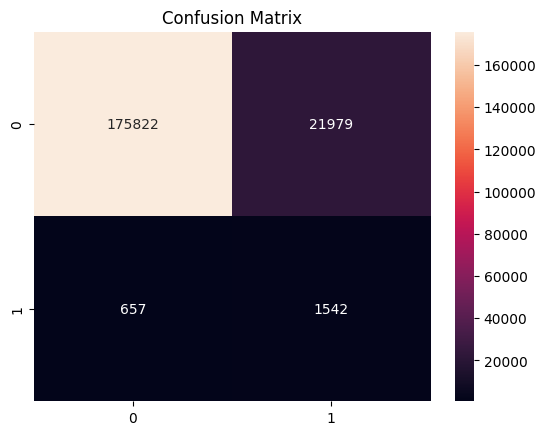

In [67]:
import seaborn as sns

cm = confusion_matrix(y_test, y_gb_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

- True Positives = 175822
    - Legit transactions correctly classified as legit
- False Positives = 21979
    - Legit transactions incorrectly flagged as fraud
- False Negatives = 657
    - Fraud cases missed by the model
- True Negatives = 1542
    - Fraud correctly detected

The confusion matrix provides a detailed view of the model’s classification performance. The model correctly identifies 1,542 fraudulent transactions while missing 657 cases, resulting in a recall of approximately 70%. This indicates that the majority of fraud cases are successfully detected, which is a key objective in fraud detection systems.

However, the model also produces a significant number of false positives, with 21,979 legitimate transactions incorrectly flagged as fraudulent. This reflects the trade-off introduced during threshold tuning, where the model is optimized to maximize fraud detection at the expense of increased false alarms.

Overall, the results demonstrate that the model prioritizes capturing fraudulent activity, even if it leads to additional investigation costs due to false positives. This behavior is consistent with real-world fraud detection strategies, where missing fraud is typically more costly than reviewing legitimate transactions.


### Train vs Test Evaluation

In [69]:
from sklearn.metrics import recall_score

# Train
y_train_pred = (gb.predict_proba(X_train)[:, 1] >= best_threshold_gb).astype(int)
print(f"Train Recall: {recall_score(y_train, y_train_pred): .3f}")

# Test
print(f"Test Recall: {recall_score(y_test, y_gb_pred): .3f}")

Train Recall:  0.711
Test Recall:  0.701


The recall score was evaluated on both the training and test datasets to assess the model’s generalization ability. The model achieved a recall of approximately 0.71 on the training set and 0.70 on the test set.

The close similarity between these values indicates that the model generalizes well to unseen data and does not suffer from significant overfitting. This suggests that the patterns learned during training are robust and transferable to new observations.

Overall, the consistency between training and test performance provides confidence in the model’s ability to reliably detect fraudulent transactions in a real-world setting.


### Final comparison summary

In [70]:
summary_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosting"],
    "Recall": [0.701, 0.701],
    "Precision": [0.057, 0.066],
    "Threshold": [0.617, 0.018],
    "Decision": ["Not selected", "Selected"]
})

summary_df.style.highlight_max(subset=["Precision"], color="lightgreen")

,Model,Recall,Precision,Threshold,Decision
0,Logistic Regression,0.701000,0.057000,0.617000,Not selected
1,Gradient Boosting,0.701000,0.066000,0.018000,Selected


### Business interpretation

The final model is designed to prioritize fraud detection, achieving a recall of approximately 70%. This means that the majority of fraudulent transactions are successfully identified.

However, this comes at the cost of low precision, indicating that many flagged transactions are actually legitimate. This trade-off is common in fraud detection systems, where the cost of missing fraud typically outweighs the inconvenience of false alerts.

In practice, this system can be used to prioritize transactions for further investigation rather than making fully automated decisions. By ranking transactions based on their fraud risk score, organizations can focus resources on the most suspicious cases and improve operational efficiency.

The flexibility of threshold tuning also allows the system to adapt to different business strategies, depending on the acceptable balance between risk and customer experience.


### Limitations and Future Improvements

While the model achieved strong performance, several limitations remain. The dataset is highly imbalanced, which makes fraud detection inherently challenging. Additionally, Logistic Regression assumes linear relationships, which may not fully capture complex interactions between features.

Future improvements could include more advanced models, feature engineering, or anomaly detection techniques. Further analysis of misclassified fraud cases could also provide insights for improving detection performance.

### Fraud Score Creation

In [71]:
df["fraud_score_ml"] = gb.predict_proba(X)[:, 1]

In [72]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,fraud_score_ml
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0,0.002405
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0,0.003679
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0,0.005787
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0,0.001660
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0,0.004001


The predicted fraud scores represent the probability of a transaction being fraudulent. Since fraud is a rare event in the dataset, most predicted probabilities are relatively low. This reflects the model’s calibration to the underlying class distribution, where the majority of transactions are legitimate.

Even though the absolute values are small, these scores are meaningful in a relative sense, allowing transactions to be ranked by risk. As a result, a low threshold is required to effectively identify potentially fraudulent transactions.


#### Machine Learning Fraud Score

The model outputs probabilities using the `predict_proba()` method, representing the likelihood of each transaction being fraudulent. The probability associated with the fraud class was extracted and stored as a new feature called `fraud_score_ml`.

This score ranges between 0 and 1 and provides a continuous measure of fraud risk. Unlike binary predictions, it allows transactions to be ranked by risk level and supports the use of flexible thresholds based on business requirements.

Since fraud is a rare event in the dataset, most predicted probabilities are relatively low. This reflects the model’s calibration to the underlying class distribution, where the majority of transactions are legitimate.

Despite their low absolute values, these probabilities remain meaningful in a relative sense, enabling effective ranking of transactions by risk. Consequently, a relatively low decision threshold is required to identify potentially fraudulent transactions.


In [73]:
df[df["fraud_bool"] == 1][["fraud_bool", "fraud_score_ml"]].head(10)

,fraud_bool,fraud_score_ml
43,1,0.041230
140,1,0.017162
284,1,0.020020
314,1,0.168801
561,1,0.045905
679,1,0.018824
728,1,0.203773
890,1,0.057862
1097,1,0.014152
1139,1,0.010948


##### Analysis of Misclassified Fraud Cases

Some fraudulent transactions were assigned relatively low predicted probabilities (e.g., below 0.3), indicating that the model failed to identify them as high-risk.

This occurs because certain fraud cases exhibit patterns similar to legitimate transactions, making them difficult to distinguish based on the available features. As a result, the model assigns lower confidence scores to these cases.

These misclassifications highlight the limitations of the model and suggest that additional features or more complex models may be required to improve detection performance.


### Improving the model

In [75]:
y_pred_final = (y_gb_proba >= best_threshold_gb).astype(int)

# Missed fraud
missed_fraud = X_test[(y_test == 1) & (y_pred_final == 0)]

# False positives
false_positives = X_test[(y_test == 0) & (y_pred_final == 1)]

In [76]:
missed_fraud.describe()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.0,657.000000
mean,0.599848,0.453525,12.732116,87.073059,35.479452,1.218577,6.540664,1646.391172,5746.971342,4782.918261,4923.658614,193.832572,9.143075,137.902588,0.627093,0.385084,0.873668,11.546423,0.158295,570.258752,0.045662,7.447493,0.528158,1.028919,0.0,3.267884
std,0.283784,0.282022,45.728534,82.881495,11.730847,6.935993,19.204097,1003.323906,3108.402531,1460.620137,1032.846462,514.306405,4.834226,69.683603,0.483946,0.486986,0.332476,12.569856,0.365296,527.097228,0.208910,8.896722,0.499587,0.242102,0.0,2.393733
min,0.100000,0.008449,-1.000000,-1.000000,10.000000,0.000031,-3.877374,65.000000,326.632727,1694.875261,3008.145870,0.000000,1.000000,-59.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,200.000000,0.000000,0.065979,0.000000,0.000000,0.0,0.000000
25%,0.400000,0.194682,-1.000000,32.000000,30.000000,0.006878,-1.190853,942.000000,3460.245955,3574.639946,4231.742511,1.000000,5.000000,85.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.128629,0.000000,1.000000,0.0,1.000000
50%,0.700000,0.432764,-1.000000,61.000000,30.000000,0.014000,-0.835228,1362.000000,5394.362212,4840.451490,4970.673166,9.000000,8.000000,133.000000,1.000000,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,4.881722,1.000000,1.000000,0.0,3.000000
75%,0.900000,0.704483,-1.000000,124.000000,40.000000,0.024134,-0.496366,2076.000000,7684.565042,5765.580539,5570.363686,19.000000,12.000000,191.000000,1.000000,1.000000,1.000000,25.000000,0.000000,1000.000000,0.000000,7.724691,1.000000,1.000000,0.0,5.000000
max,0.900000,0.999730,333.000000,384.000000,80.000000,75.495921,105.826249,6262.000000,15738.886343,9065.825750,6825.579247,2121.000000,26.000000,338.000000,1.000000,1.000000,1.000000,31.000000,1.000000,2000.000000,1.000000,65.165869,1.000000,2.000000,0.0,7.000000


In [77]:
false_positives.describe()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,2.197900e+04,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.000000,21979.0,21979.000000
mean,0.686564,0.393383,4.340643,126.261022,41.025069,8.105298e-01,3.911699,1594.463488,5195.327609,4556.758874,4738.240372,149.687929,7.380727,177.712953,0.631830,0.269803,0.857091,10.161427,0.096911,803.838664,0.035443,8.076168,0.338095,1.075754,0.0,3.559352
std,0.270140,0.299193,28.824722,86.037279,12.658325,4.665889e+00,16.683046,1016.027584,2831.594266,1427.362503,920.501743,422.276203,4.718040,79.699000,0.482319,0.443867,0.349988,12.638864,0.295843,597.408455,0.184901,8.916028,0.473072,0.305623,0.0,2.183515
min,0.100000,0.000058,-1.000000,-1.000000,10.000000,7.760450e-07,-11.652876,33.000000,-170.603072,1493.833927,2974.182964,0.000000,0.000000,-154.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.600000,0.131398,-1.000000,61.000000,30.000000,6.447750e-03,-1.184878,902.000000,3075.227614,3393.421415,4213.807811,1.000000,4.000000,116.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.244280,0.000000,1.000000,0.0,2.000000
50%,0.800000,0.280132,-1.000000,110.000000,40.000000,1.369224e-02,-0.890289,1265.000000,5020.726719,4566.125138,4816.207837,3.000000,7.000000,181.000000,1.000000,0.000000,1.000000,2.000000,0.000000,500.000000,0.000000,5.337065,0.000000,1.000000,0.0,4.000000
75%,0.900000,0.679369,-1.000000,172.000000,50.000000,2.435142e-02,-0.558638,1977.000000,6974.924685,5461.681269,5329.998118,16.000000,10.000000,238.000000,1.000000,1.000000,1.000000,25.000000,0.000000,1500.000000,0.000000,9.238810,1.000000,1.000000,0.0,5.000000
max,0.900000,0.999991,356.000000,395.000000,90.000000,7.544056e+01,111.659817,6353.000000,16284.567254,9332.386758,6941.546886,2359.000000,36.000000,389.000000,1.000000,1.000000,1.000000,31.000000,1.000000,2100.000000,1.000000,74.927846,1.000000,2.000000,0.0,7.000000


### Error Analysis: Missed Fraud vs False Positives

The analysis of missed fraud cases (false negatives) reveals that these transactions tend to exhibit characteristics that closely resemble legitimate customer behavior. Specifically, they show higher values in features such as name-email similarity, banking activity frequency, and account longevity, suggesting a more consistent and established profile.

At the same time, these transactions are associated with lower financial indicators, including income, customer age, credit risk score, and proposed credit limit. This indicates that the missed fraud cases are not driven by extreme or suspicious behavioral patterns, but rather by more subtle financial vulnerabilities.

This combination makes such fraud particularly challenging to detect, as it does not trigger the strong signals typically learned by the model. As a result, these cases represent a key limitation of the current approach and highlight an opportunity for improvement, potentially through additional features or more advanced modeling techniques.



## Conclusion

This project aimed to develop a fraud detection system capable of identifying potentially fraudulent transactions using both rule-based logic and machine learning models. By combining multiple data dimensions—including financial behavior, customer characteristics, transactional patterns, and identity features—we were able to build a comprehensive and interpretable framework for fraud risk assessment.

Several models were evaluated, including Logistic Regression, Random Forest, and Gradient Boosting. While initial comparison using ROC-AUC showed similar performance between Logistic Regression and Gradient Boosting, further evaluation using precision-recall analysis and threshold tuning revealed more meaningful differences. In particular, Gradient Boosting demonstrated a better balance between recall and precision, making it more suitable for the business objective of maximizing fraud detection while controlling false positives.

The final model achieved a recall of approximately 70%, meaning that a significant proportion of fraudulent transactions are successfully identified. However, this comes at the cost of low precision, with a high number of false positives. This trade-off is expected and acceptable in fraud detection contexts, where missing fraudulent activity is typically more costly than incorrectly flagging legitimate transactions.

The use of probability-based scoring enabled flexible threshold tuning, allowing the model to adapt to different business requirements. This approach also supports the ranking of transactions by risk level, which can be used to prioritize investigations and optimize operational workflows.

Further analysis of model errors provided valuable insights. Missed fraud cases were found to resemble legitimate transactions in behavioral patterns, making them more difficult to detect. This highlights a limitation of the current model and suggests that additional features or more advanced modeling techniques may be required to capture these subtle patterns.

Overall, the Gradient Boosting model was selected as the final solution due to its superior performance in precision-recall trade-offs and its ability to capture complex relationships in the data. The resulting system provides a solid foundation for fraud detection, combining predictive performance with interpretability and practical business applicability.


#### Tableau

In [78]:
# df["fraud_pred"] = (df["fraud_score_ml"] >= best_threshold_gb).astype(int)

In [79]:
# df.to_csv("fraud_dashboard.csv", index=False)

In [80]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,fraud_score_ml,fraud_pred
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0,0.002405,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0,0.003679,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0,0.005787,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0,0.001660,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0,0.004001,0


In [83]:
df["has_other_cards"].unique()

array([0, 1])